In [0]:
# =============================================================================
# 1. LISTA STAZIONI GLOBALI 
# =============================================================================

from pyspark.sql import functions as F

# Struttura: continente → paese → [USAF codes + nome città breve]
global_stations = {
    "Europa": {
        "Italia":          ["160200", "162390", "164050"],      # Bolzano, Roma Ciampino, Palermo Punta Raisi
        "Francia":         ["071300", "076500", "071490"],      # Parigi CDG, Marsiglia, Brest
        "Germania":        ["103840", "108700", "101470"],      # Berlino, Monaco, Amburgo
        "Spagna":          ["080010", "083140", "081910"],      # Madrid Barajas, Barcellona, Malaga
        "Regno Unito":     ["037720", "038080", "030910"]       # Londra Heathrow, Birmingham, Aberdeen
    },
    "Asia": {
        "Cina":            ["545110", "582380", "592870"],      # Pechino, Shanghai, Guangzhou
        "India":           ["421820", "430630", "432790"],      # Delhi, Mumbai, Chennai
        "Giappone":        ["476620", "477700", "479710"],      # Tokyo, Osaka, Naha Okinawa
        "Russia":          ["260380", "284500", "319600"],      # Mosca, Novosibirsk, Sochi
        "Indonesia":       ["967490", "967410", "971800"]       # Jakarta, Surabaya, Denpasar Bali
    },
    "Africa": {
        "Sudafrica":       ["688160", "683680", "689940"],      # Cape Town, Johannesburg, Durban
        "Nigeria":         ["650460", "650820", "651670"],      # Lagos, Kano, Abuja
        "Egitto":          ["623970", "624140", "624200"],      # Il Cairo, Alessandria, Assuan
        "Kenya":           ["637400", "637910", "636860"],      # Nairobi, Mombasa, Eldoret
        "Marocco":         ["601550", "602650", "602200"]       # Casablanca, Marrakech, Tangeri
    },
    "Nord America": {
        "Stati Uniti":     ["725030", "722950", "722740"],      # New York JFK, Los Angeles, Miami
        "Canada":          ["716240", "718920", "719360"],      # Toronto, Vancouver, Montreal
        "Messico":         ["766790", "764580", "766440"],      # Città del Messico, Monterrey, Cancun
        "Cuba":            ["783970", "783250"],                # L'Avana, Santiago de Cuba
        "Guatemala":       ["786660"]                           # Città del Guatemala (solo una per semplicità)
    },
    "Sud America": {
        "Brasile":         ["837800", "839070", "823320"],      # Rio de Janeiro, San Paolo, Manaus
        "Argentina":       ["876330", "871780", "877650"],      # Buenos Aires, Cordoba, Ushuaia
        "Cile":            ["855860", "854700"],                # Santiago, Punta Arenas
        "Colombia":        ["802590", "802220"],                # Bogotà, Cartagena
        "Perù":            ["846280", "846860"]                 # Lima, Cuzco
    },
    "Oceania": {
        "Australia":       ["946720", "948660", "946380", "942990", "946370"],  # Sydney, Melbourne, Perth, Darwin, Adelaide
        "Nuova Zelanda":   ["936140", "934170", "936780"]       # Auckland, Christchurch, Wellington
    }
}

# Flatten in lista di codici USAF
usaf_list = []
for continente, paesi in global_stations.items():
    for paese, codes in paesi.items():
        usaf_list.extend(codes)

print(f"Numero totale stazioni selezionate: {len(usaf_list)}")
print("Primi 10 codici USAF:", usaf_list[:10])
print("Esempio ultimo continente:", global_stations["Oceania"])

# Crea DataFrame Spark con metadati stazioni (opzionale, per join/filtro facile)
stations_df = spark.createDataFrame(
    [(code,) for code in usaf_list],
    ["USAF"]
).withColumn("station_pattern", F.concat(F.col("USAF"), F.lit("99999")))

Numero totale stazioni selezionate: 77
Primi 10 codici USAF: ['160200', '162390', '164050', '071300', '076500', '071490', '103840', '108700', '101470', '080010']
Esempio ultimo continente: {'Australia': ['946720', '948660', '946380', '942990', '946370'], 'Nuova Zelanda': ['936140', '934170', '936780']}


In [0]:
# =============================================================================
# Lettura sicura da S3 con gestione errori e log dei mancanti
# =============================================================================

from pyspark.sql import functions as F
import pyspark.sql.types as T

# 2. Mappa piatta USAF → (continente, paese, città breve)
usaf_to_info = {}
for continente, paesi in global_stations.items():
    for paese, codes in paesi.items():
        for i, code in enumerate(codes):
            city_name = f"{paese} {i+1}"  # placeholder – puoi migliorare con nomi reali
            if continente == "Europa" and paese == "Italia":
                names = ["Bolzano", "Roma Ciampino", "Palermo"]
                city_name = names[i] if i < len(names) else f"{paese} {i+1}"
            # Aggiungi altri if per continenti/paesi se vuoi nomi precisi
            usaf_to_info[code] = {
                "continente": continente,
                "paese": paese,
                "city": city_name
            }

# 3. Genera lista percorsi
years = list(range(2000, 2025))
paths_with_info = []
for year in years:
    for code in usaf_to_info.keys():
        path = f"s3a://noaa-gsod-pds/{year}/{code}99999.csv"
        paths_with_info.append((path, code, year))

print(f"Totale percorsi generati: {len(paths_with_info)}")

# 4. Lettura uno alla volta con try/except
dfs = []
missing_files = []

for path, usaf, year in paths_with_info:
    try:
        df_temp = spark.read \
            .option("header", "true") \
            .option("inferSchema", "true") \
            .csv(path)
        
        if df_temp.count() > 0:
            df_temp = df_temp.withColumn("USAF", F.lit(usaf)) \
                             .withColumn("year", F.lit(year))
            dfs.append(df_temp)
        else:
            missing_files.append((usaf, year, "file vuoto"))
    except Exception as e:
        # Qui catturiamo il path mancante
        city_info = usaf_to_info.get(usaf, {"city": "Sconosciuta"})
        missing_files.append((usaf, year, city_info["city"], str(e)))

# 5. Unione di tutti i DataFrame validi
if dfs:
    df_global = dfs[0]
    for df in dfs[1:]:
        df_global = df_global.unionByName(df, allowMissingColumns=True)
    
    # Aggiungi stagione
    df_global = df_global.withColumn(
        "season",
        F.when(F.month("DATE").isin([12,1,2]), "Inverno")
         .when(F.month("DATE").isin([3,4,5]), "Primavera")
         .when(F.month("DATE").isin([6,7,8]), "Estate")
         .otherwise("Autunno")
    )
    
    print(f"\nRighe totali lette con successo: {df_global.count()}")
    display(df_global.limit(10))
else:
    print("Nessun file valido trovato!")

# 6. Report file mancanti (con nome città)
if missing_files:
    print("\n=== FILE MANCANTI O VUOTI ===")
    print(f"Totale mancanti: {len(missing_files)}")
    for item in missing_files:
        if len(item) == 4:
            usaf, year, city, error = item
            print(f"USAF {usaf} ({city}) - Anno {year} → {error}")
        else:
            usaf, year, reason = item
            print(f"USAF {usaf} - Anno {year} → {reason}")

Totale percorsi generati: 1925


In [0]:
# ============================================================================= 
# ETL + Aggiunta città/regione + Controllo unità + Salvataggio Delta
# ============================================================================= 

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Assumi df_global sia già letto dal codice precedente (con colonne NOAA CSV)
# Se non ce l'hai, ri-esegui la lettura sicura

# 1. Estrai città pulita da NAME (es. "ROMA CIAMPINO, IT" → "Roma Ciampino")
df_etl = df_global.withColumn(
    "city_raw",
    F.split(F.col("NAME"), ",")[0]  # prima parte prima della virgola/paese
).withColumn(
    "city",
    F.trim(
        F.regexp_replace(
            F.regexp_replace(F.col("city_raw"), "(AIRPORT|AP|INTL|MUNI|FIELD|STATION)", ""),
            r"\s+", " "
        )
    )
).withColumn(
    "region",
    F.when(F.col("LATITUDE") > 45, "Nord")
     .when(F.col("LATITUDE").between(35, 45), "Centro")
     .otherwise("Sud")
).drop("city_raw", "NAME")  # puliamo

# 2. Controllo se le temperature sono già in °C o ancora in °F
# Regola empirica: se media TEMP > 40 → quasi sicuramente °F
temp_stats = df_etl.agg(
    F.avg("TEMP").alias("avg_TEMP"),
    F.max("TEMP").alias("max_TEMP"),
    F.min("TEMP").alias("min_TEMP")
).collect()[0]

print("Statistiche TEMP raw:")
print(f"Media: {temp_stats['avg_TEMP']:.2f} | Max: {temp_stats['max_TEMP']:.2f} | Min: {temp_stats['min_TEMP']:.2f}")

if temp_stats['avg_TEMP'] > 40 or temp_stats['max_TEMP'] > 50:
    print("→ Temperature in °F → Converto in °C")
    df_etl = df_etl.withColumn("TEMP_c",   (F.col("TEMP") - 32) * 5/9) \
                   .withColumn("MAX_c",    (F.col("MAX") - 32) * 5/9) \
                   .withColumn("MIN_c",    (F.col("MIN") - 32) * 5/9)
else:
    print("→ Temperature già in °C → rinomino colonne")
    df_etl = df_etl.withColumnRenamed("TEMP", "TEMP_c") \
                   .withColumnRenamed("MAX", "MAX_c") \
                   .withColumnRenamed("MIN", "MIN_c")

# 3. Filtra righe valide (almeno temperatura)
df_etl_clean = df_etl.filter(F.col("TEMP_c").isNotNull())

print("Righe dopo ETL e filtro:", df_etl_clean.count())

# Anteprima
display(df_etl_clean.select(
    "STATION", "city", "region", "DATE", "year", "season", "TEMP_c", "MAX_c", "MIN_c", "PRCP"
).limit(10))


Statistiche TEMP raw:
Media: 58.85 | Max: 101.50 | Min: 20.80
→ Temperature in °F → Converto in °C
Righe dopo ETL e filtro: 53960


STATION,city,region,DATE,year,season,TEMP_c,MAX_c,MIN_c,PRCP
16020099999,BOLZANO,Nord,2000-01-01,2000,Inverno,-4.555555555555555,1.722222222222223,-10.11111111111111,0.0
16020099999,BOLZANO,Nord,2000-01-02,2000,Inverno,-4.166666666666667,2.3888888888888875,-11.222222222222221,0.0
16020099999,BOLZANO,Nord,2000-01-03,2000,Inverno,-1.6111111111111103,5.611111111111112,-8.5,0.0
16020099999,BOLZANO,Nord,2000-01-04,2000,Inverno,-1.9444444444444444,4.777777777777779,-8.0,0.0
16020099999,BOLZANO,Nord,2000-01-05,2000,Inverno,-0.8888888888888897,6.277777777777776,-7.777777777777778,0.0
16020099999,BOLZANO,Nord,2000-01-06,2000,Inverno,-0.6666666666666663,5.999999999999998,-8.0,0.0
16020099999,BOLZANO,Nord,2000-01-07,2000,Inverno,-1.2777777777777781,5.0,-7.277777777777778,0.0
16020099999,BOLZANO,Nord,2000-01-08,2000,Inverno,-1.2222222222222219,5.0,-7.888888888888889,0.0
16020099999,BOLZANO,Nord,2000-01-09,2000,Inverno,-1.2222222222222219,2.7222222222222214,-4.0,0.0
16020099999,BOLZANO,Nord,2000-01-10,2000,Inverno,-0.6111111111111119,5.0,-6.888888888888888,0.0


In [0]:
# 4. Salva in Delta (versionato, riutilizzabile)
delta_path = "/Volumes/workspace/weather/global_weather/"  # adatta al tuo Volume

df_etl_clean.write.format("delta").mode("overwrite").save(delta_path)

print(f"Salvato in Volume: {delta_path}")

Salvato in Volume: /Volumes/workspace/weather/global_weather/


In [0]:
# =============================================================================
# Calcola Statistiche + Top10 con Window Ranking
# =============================================================================

# Ricarica da Delta se vuoi (opzionale, per riuso futuro)
df_etl_clean = spark.read.format("delta").load(delta_path)

# Aggregazioni di base per città/anno/stagione
stats = df_etl_clean.groupBy("city", "region", "year", "season") \
    .agg(
        F.avg("TEMP_c").alias("avg_temp_c"),
        F.max("MAX_c").alias("max_temp_c"),
        F.min("MIN_c").alias("min_temp_c"),
        F.sum("PRCP").alias("total_prcp_mm"),
        F.count(F.when(F.col("PRCP") > 10, True)).alias("giorni_prcp_gt_10mm"),
        F.count(F.when(F.col("MAX_c") > 35, True)).alias("giorni_sopra_35c")
    ).orderBy("city", "year", "season")

print("Esempio statistiche:")
#display(stats.limit(20))

# Top10 globali (es. città con avg temp più alta in un anno specifico)
top_hot_year = stats.filter(F.col("year") == 2023) \
    .orderBy(F.desc("avg_temp_c")) \
    .limit(10)

#display(top_hot_year)  # Top10 città più calde nel 2023

# Window ranking: Top10 città più calde di sempre (media annuale)
window_global = Window.orderBy(F.desc("avg_temp_c"))

top_hot_alltime = stats.withColumn(
    "global_rank", F.row_number().over(window_global)
).filter(F.col("global_rank") <= 10)

#display(top_hot_alltime.select("city", "region", "year", "season", "avg_temp_c", "global_rank"))

# Top10 per giorni prcp >10mm (più piovose)
window_rain = Window.orderBy(F.desc("giorni_prcp_gt_10mm"))

top_rainy = stats.withColumn(
    "rain_rank", F.row_number().over(window_rain)
).filter(F.col("rain_rank") <= 10)

#display(top_rainy.select("city", "region", "year", "season", "giorni_prcp_gt_10mm", "rain_rank"))

# Visualizzazione interattiva esempio
#display(stats.select("city", "year", "avg_temp_c"))  # → scegli Line chart, serie per city

Esempio statistiche:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
#  50€ di quello a 8€

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Assumi df_etl_clean sia già pronto (da ETL precedente)

# 1. Aggrega per paese/anno (media delle città del paese)
country_stats = df_etl_clean.groupBy("paese", "year") \
    .agg(
        F.avg("TEMP_c").alias("avg_temp_c_country"),
        F.sum("PRCP").alias("total_prcp_mm_country")
    )

# 2. Aggrega per continente/anno (media dei paesi nel continente)
continent_stats = country_stats.groupBy("continente", "year") \
    .agg(
        F.avg("avg_temp_c_country").alias("avg_temp_c_continent"),
        F.avg("total_prcp_mm_country").alias("avg_prcp_mm_continent")
    ).orderBy("continente", "year")

display(continent_stats)  # Tabella + Line chart per trend

# 3. Ranking: Top continenti più caldi/piovosi (media annuale)
window_continent = Window.orderBy(F.desc("avg_temp_c_continent"))

continent_rank = continent_stats.withColumn(
    "rank_caldo_continent",
    F.row_number().over(window_continent)
).filter(F.col("year") == 2023)  # es. ultimo anno completo

display(continent_rank.select("continente", "year", "avg_temp_c_continent", "rank_caldo_continent"))

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-7312994855173257>, line 20
     13 # 2. Aggrega per continente/anno (media dei paesi nel continente)
     14 continent_stats = country_stats.groupBy("continente", "year") \
     15     .agg(
     16         F.avg("avg_temp_c_country").alias("avg_temp_c_continent"),
     17         F.avg("total_prcp_mm_country").alias("avg_prcp_mm_continent")
     18     ).orderBy("continente", "year")
---> 20 display(continent_stats)  # Tabella + Line chart per trend
     22 # 3. Ranking: Top continenti più caldi/piovosi (media annuale)
     23 window_continent = Window.orderBy(F.desc("avg_temp_c_continent"))

File /databricks/python_shell/lib/dbruntime/display.py:133, in Display.display(self, input, *args, **kwargs)
    131     pass
    132 elif self._cf_helper is not None and isinstance(input, ConnectDataFrame):
--> 133     self.display_

city,year,avg_temp_c,max_temp_c,min_temp_c,total_prcp_mm,giorni_prcp_gt_10mm,giorni_prcp_gt_50mm,giorni_sopra_35c,giorni_gelo,avg_wind_knots,max_gust_knots,avg_humidity_pct,giorni_fulmini,baseline_avg_temp_c,anomalia_temp_c
ST JACQUES,2001,12.191476407914767,35.72222222222222,-5.388888888888889,130.35999999999999,1,1,1,38,7.209863013698631,999.9,465.3049883396908,0,12.034276312150872,0.15720009576389415
ST JACQUES,2004,11.89875531268974,34.27777777777778,-5.388888888888889,23.370000000000022,0,0,0,37,6.951092896174863,999.9,527.7750205946566,1,12.034276312150872,-0.13552099946113216
ORLY,2000,11.982392228293858,32.0,-7.5,628.3199999999988,6,6,0,18,8.295628415300552,999.9,459.1301603018082,3,11.984381178331363,-0.0019889500375054325
BOLZANO,2001,12.022374429223753,5537.722222222223,-11.722222222222221,1828.3699999999992,18,18,1,90,30.36876712328768,999.9,587.5022652060476,1,12.841346007372879,-0.8189715781491262
ST JACQUES,2000,12.272009714632661,33.27777777777778,-4.888888888888889,329.60999999999916,3,3,0,24,7.100546448087436,999.9,429.11443300858565,3,12.034276312150872,0.23773340248178876
PROVENCE,2005,14.91704718417048,35.388888888888886,-6.777777777777778,16.689999999999998,0,0,1,59,9.674246575342464,999.9,502.5076169896508,0,15.606422703510091,-0.6893755193396114
ST JACQUES,2008,11.49438372799028,30.38888888888889,-5.277777777777778,29.56000000000001,0,0,0,34,6.803825136612023,999.9,343.2991696003147,6,12.034276312150872,-0.5398925841605919
PROVENCE,2003,16.138203957382043,38.0,-6.611111111111111,19.07999999999999,0,0,18,25,8.977808219178087,999.9,352.4846386604026,0,15.606422703510091,0.5317812538719515
ORLY,2003,12.478691019786906,40.0,-8.5,18.289999999999985,0,0,11,49,6.78465753424658,999.9,539.629349841757,1,11.984381178331363,0.4943098414555429
ST JACQUES,2003,12.872450532724507,39.5,-7.277777777777778,24.10000000000001,0,0,8,34,6.719178082191781,999.9,329.5159882195747,0,12.034276312150872,0.8381742205736344


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


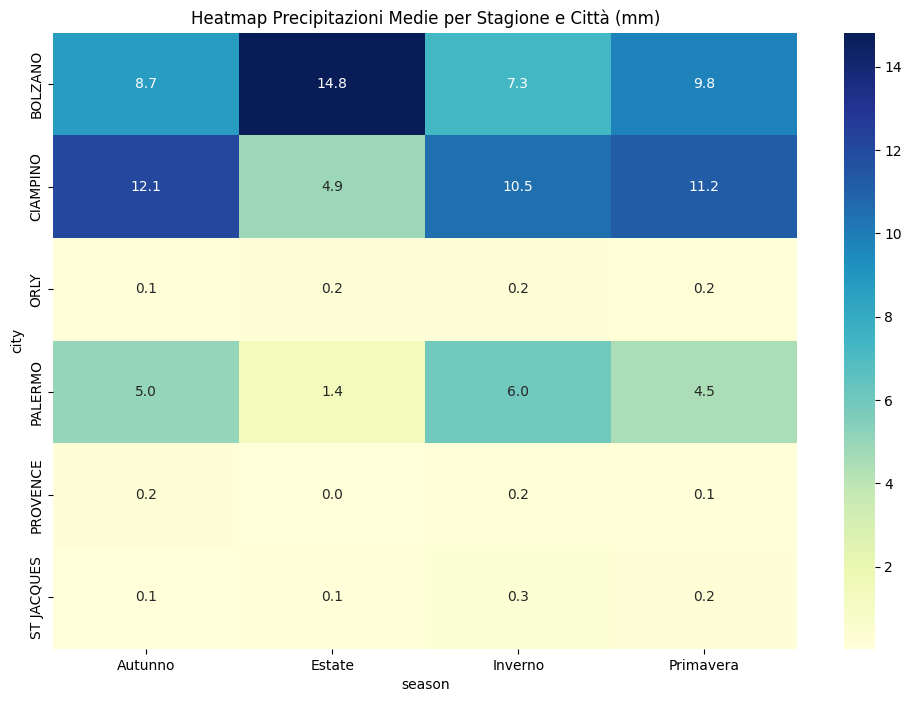

In [0]:
# =============================================================================
# Aggregazioni Statistiche Estese (per visualizzazioni)
# =============================================================================

# Baseline per anomalie (media temp 2000-2010 per città)
baseline = df_etl_clean.filter(F.col("year").between(2000, 2010)) \
    .groupBy("city") \
    .agg(F.avg("TEMP_c").alias("baseline_avg_temp_c"))

# Statistiche estese per città/anno
extended_stats = df_etl_clean.groupBy("city", "year") \
    .agg(
        F.avg("TEMP_c").alias("avg_temp_c"),
        F.max("MAX_c").alias("max_temp_c"),
        F.min("MIN_c").alias("min_temp_c"),
        F.sum("PRCP").alias("total_prcp_mm"),
        F.count(F.when(F.col("PRCP") > 10, True)).alias("giorni_prcp_gt_10mm"),
        F.count(F.when(F.col("PRCP") > 50, True)).alias("giorni_prcp_gt_50mm"),
        F.count(F.when(F.col("MAX_c") > 35, True)).alias("giorni_sopra_35c"),
        F.count(F.when(F.col("MIN_c") < 0, True)).alias("giorni_gelo"),
        F.avg("WDSP").alias("avg_wind_knots"),
        F.max("GUST").alias("max_gust_knots"),
        F.avg(F.when(F.col("TEMP_c") != 0, (F.col("DEWP") / F.col("TEMP_c")) * 100)).alias("avg_humidity_pct"),
        F.count(F.when(F.substring("FRSHTT", 5, 1) == "1", True)).alias("giorni_fulmini")
    ).join(baseline, "city", "left") \
    .withColumn("anomalia_temp_c", F.col("avg_temp_c") - F.col("baseline_avg_temp_c"))

display(extended_stats.limit(20))

# =============================================================================
# Visualizzazioni con Plotly (interattivo) e Seaborn (statico)
# =============================================================================

%pip install plotly seaborn --quiet

import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Converti in Pandas (dataset aggregato piccolo)
pdf = extended_stats.toPandas()

# Plotly Line per trend temp media per città
fig_line = px.line(
    pdf,
    x="year",
    y="avg_temp_c",
    color="city",
    markers=True,
    title="Trend Temperatura Media Annuale per Città",
    labels={"avg_temp_c": "Temp Media (°C)", "year": "Anno"}
)
fig_line.update_layout(hovermode="x unified")
fig_line.show()

# Plotly Scatter per anomalie (size per giorni sopra 35°C)
fig_scatter = px.scatter(
    pdf,
    x="year",
    y="anomalia_temp_c",
    color="city",
    size="giorni_sopra_35c",
    title="Anomalie Temperatura vs Baseline (Size: Giorni >35°C)",
    labels={"anomalia_temp_c": "Anomalia (°C)"}
)
fig_scatter.show()

# Seaborn Heatmap per statistiche stagionali (es. prcp per città/season)
seasonal_pdf = df_etl_clean.groupBy("city", "season") \
    .agg(F.avg("PRCP").alias("avg_prcp_mm")).toPandas()

plt.figure(figsize=(12, 8))
pivot = seasonal_pdf.pivot(index="city", columns="season", values="avg_prcp_mm")
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Heatmap Precipitazioni Medie per Stagione e Città (mm)")
plt.show()

# Plotly Bar per top10 città più piovose (giorni >10mm)
top_rain_pdf = pdf.sort_values("giorni_prcp_gt_10mm", ascending=False).head(10)
fig_bar = px.bar(
    top_rain_pdf,
    x="city",
    y="giorni_prcp_gt_10mm",
    color="year",
    title="Top10 Città per Giorni con PRCP >10mm"
)
fig_bar.show()